## Data Accessing

#### Types of unclean data

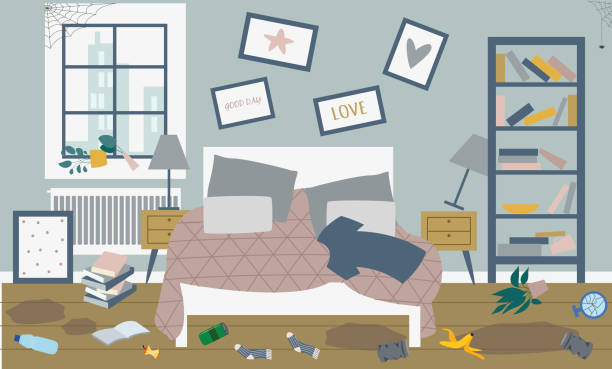

In [78]:
import pandas as pd
import numpy as np

In [79]:
patients = pd.read_csv('datasets/patients.csv')
treatments = pd.read_csv('datasets/treatments.csv')
adverse_reactions = pd.read_csv('datasets/adverse_reactions.csv')
treatments_cut = pd.read_csv('datasets/treatments_cut.csv')

In [80]:
patients

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,951-719-9170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de+1 (217) 569-3204,4/3/1967,118.8,66,19.2
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,402-363-6804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com+1 (732) 636-8246,7/26/1951,220.9,70,31.7
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,334-515-7487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,207-477-0579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,928-284-4492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,816-223-6007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com1 360 443 2060,2/13/1952,176.9,67,27.7


In [81]:
treatments.head()

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
0,veronika,jindrová,41u - 48u,-,7.63,7.20,NaN
1,elliot,richardson,-,40u - 45u,7.56,7.09,0.97
2,yukitaka,takenaka,-,39u - 36u,7.68,7.25,NaN
3,skye,gormanston,33u - 36u,-,7.97,7.62,0.35
4,alissa,montez,-,33u - 29u,7.78,7.46,0.32


In [82]:
treatments_cut.head()

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
0,jožka,resanovič,22u - 30u,-,7.56,7.22,0.34
1,inunnguaq,heilmann,57u - 67u,-,7.85,7.45,NaN
2,alwin,svensson,36u - 39u,-,7.78,7.34,NaN
3,thể,lương,-,61u - 64u,7.64,7.22,0.92
4,amanda,ribeiro,36u - 44u,-,7.85,7.47,0.38


In [83]:
adverse_reactions

,given_name,surname,adverse_reaction
0,berta,napolitani,injection site discomfort
1,lena,baer,hypoglycemia
2,joseph,day,hypoglycemia
3,flavia,fiorentino,cough
4,manouck,wubbels,throat irritation
5,jasmine,sykes,hypoglycemia
6,louise,johnson,hypoglycemia
7,albinca,komavec,hypoglycemia
8,noe,aranda,hypoglycemia
9,sofia,hermansen,injection site discomfort


### 1. Write a summary for your data

This is a dataset about 500 patients of which 350 patients participated in a clinical trial. None of the patients were using Novodra (a popular injectable insulin) or Auralin (the oral insulin being researched) as their primary source of insulin before. All were experiencing elevated HbA1c levels.

All 350 patients were treated with Novodra to establish a baseline HbA1c level and insulin dose. After 4 weeks, which isn’t enough time to capture all the change in HbA1c that can be attributed by the switch to Auralin or Novodra:

- 175 patients switched to Auralin for 24 weeks
- 175 patients continued using Novodra for 24 weeks

Data about patients feeling some adverse effects is also recorded.

### 2. Write Column descriptions

#### **Table** -> `patients`:

- `patient_id`: the unique identifier for each patient in the Master Patient Index (i.e. patient database) of the pharmaceutical company that is producing Auralin
- `assigned_sex`: the assigned sex of each patient at birth (male or female)
- `given_name`: the given name (i.e. first name) of each patient
- `surname`: the surname (i.e. last name) of each patient
- `address`: the main address for each patient
- `city`: the corresponding city for the main address of each patient
- `state`: the corresponding state for the main address of each patient
- `zip_code`: the corresponding zip code for the main address of each patient
- `country`: the corresponding country for the main address of each patient (all United states for this clinical trial)
- `contact`: phone number and email information for each patient
- `birthdate`: the date of birth of each patient (month/day/year). The inclusion criteria for this clinical trial is age >= 18 (there is no maximum age because diabetes is a growing problem among the elderly population)
- `weight`: the weight of each patient in pounds (lbs)
- `height`: the height of each patient in inches (in)
- `bmi`: the Body Mass Index (BMI) of each patient. BMI is a simple calculation using a person's height and weight. The formula is BMI = kg/m2 where kg is a person's weight in kilograms and m2 is their height in metres squared. A BMI of 25.0 or more is overweight, while the healthy range is 18.5 to 24.9. The inclusion criteria for this clinical trial is 16 >= BMI >= 38.

#### **Table** -> `adverse_reactions`

- `given_name`: the given name of each patient in the Master Patient Index that took part in the clinical trial and had an adverse reaction (includes both patients treated Auralin and Novodra)
- `surname`: the surname of each patient in the Master Patient Index that took part in the clinical trial and had an adverse reaction (includes both patients treated Auralin and Novodra)
- `adverse_reaction`: the adverse reaction reported by the patient

### 3. Add any additional information

Additional useful information:

- Insulin resistance varies person to person, which is why both starting median daily dose and ending median daily dose are required, i.e., to calculate change in dose.
- It is important to test drugs and medical products in the people they are meant to help. People of different age, race, sex, and ethnic group must be included in clinical trials. This diversity is reflected in the patients table.

### Types of Assessment
There are 2 types of assessment styles

- `Manual` - Looking through the data manually in google sheets
- `Programmatic` - By using pandas functions such as info(), describe() or sample()

### Steps in Assessment
There are 2 steps involved in Assessment

- Discover
- Document

### export data for mannul assessment

In [84]:
with pd.ExcelWriter('clinical_trials.xlsx') as writer:
    patients.to_excel(writer, sheet_name = 'patients')
    treatments.to_excel(writer, sheet_name='treatments')
    treatments_cut.to_excel(writer, sheet_name='treatments_cut')
    adverse_reactions.to_excel(writer, sheet_name='adverse_reactions')

### Issues with the dataset

1. Dirty Data

  Table - `Patients`

    - patient_id = 9 has misspelled name 'Dsvid' instead of David `accuracy`
    - state col sometimes contain full name and some times abbrivietation `consistency`
    - zip code col has entries with 4 digit `validity`
    - data missing for 12 patients in address,city,	state,zip_code	,country,	contact `completion`
    - incorrect data type assigned to sex, zip code, birthdate `validity`
    - duplicate entries by the name of John Doe `accuracy`
    - one patient has weight = 48 pounds `accuracy`
    - one patient has height = 27 inches `accuracy`

  Table - `Treatments` & `Treatments_cut`

    - given_name and surname col is is all lower case `consistency`
    - remove u from Auralin and Novadra cols `validity`
    - '-' in novadra and Auralin col treated as nan `validity`
    - missing values in hba1c_change col `completion`
    - 1 duplicate entry by the name Joseph day `accuracy`
    - in hba1c_change 9 instead of 4 `accuracy`

  Table - `Adverse_reactions`

    - given_name and surname are all in lower case `consistency`

2. Messy Data

  Table - `Patients`

    - contact col contains both phone and email

  Table - `Treatments` & `Treatments_cut`

    - Auralin and Novadra col should be split into 2 cols start and end dose
    - merge both the tables

  Table - `Adverse_reactions`

    - This table should not exist independently

### Automatic Assessment

- head and tail
- sample
- info
- isnull
- duplicated
- describe

In [85]:
patients.head()

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,951-719-9170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de+1 (217) 569-3204,4/3/1967,118.8,66,19.2
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,402-363-6804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com+1 (732) 636-8246,7/26/1951,220.9,70,31.7
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,334-515-7487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1


In [86]:
patients.tail()

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,207-477-0579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,928-284-4492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,816-223-6007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com1 360 443 2060,2/13/1952,176.9,67,27.7
502,503,male,Pat,Gersten,2778 North Avenue,Burr,Nebraska,68324.0,United States,PatrickGersten@rhyta.com402-848-4923,5/3/1954,138.2,71,19.3


In [87]:
patients.sample(5)

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
213,214,female,Onyemaechi,Onwughara,685 Duncan Avenue,New York,NY,10013.0,United States,917-622-9142OnyemaechiOnwughara@einrot.com,3/8/1989,131.1,69,19.4
412,413,male,Finlay,Sheppard,4571 Walnut Hill Drive,Portland,OH,45204.0,United States,FinlaySheppard@fleckens.hu+1 (513) 297-6359,6/16/1948,161.3,70,23.1
368,369,male,Corey,Nicholls,3427 Gerald L. Bates Drive,Boston,MA,2110.0,United States,CoreyNicholls@jourrapide.com1 617 830 7216,4/25/1989,165.0,74,21.2
270,271,female,Jowita,Wiśniewska,2168 Butternut Lane,Granite City,Illinois,62040.0,United States,JowitaWisniewska@armyspy.com+1 (618) 512-3319,11/8/1934,108.1,61,20.4
145,146,male,Sauli,Koivuniemi,1990 Spring Avenue,Eagleville,PA,19403.0,United States,SauliKoivuniemi@einrot.com+1 (267) 679-4137,7/24/1974,170.9,66,27.6


In [88]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    503 non-null    int64  
 1   assigned_sex  503 non-null    object 
 2   given_name    503 non-null    object 
 3   surname       503 non-null    object 
 4   address       491 non-null    object 
 5   city          491 non-null    object 
 6   state         491 non-null    object 
 7   zip_code      491 non-null    float64
 8   country       491 non-null    object 
 9   contact       491 non-null    object 
 10  birthdate     503 non-null    object 
 11  weight        503 non-null    float64
 12  height        503 non-null    int64  
 13  bmi           503 non-null    float64
dtypes: float64(3), int64(2), object(9)
memory usage: 55.1+ KB


In [89]:
patients[patients['address'].isnull()]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
209,210,female,Lalita,Eldarkhanov,NaN,NaN,NaN,NaN,NaN,NaN,8/14/1950,143.4,62,26.2
219,220,male,Mỹ,Quynh,NaN,NaN,NaN,NaN,NaN,NaN,4/9/1978,237.8,69,35.1
230,231,female,Elisabeth,Knudsen,NaN,NaN,NaN,NaN,NaN,NaN,9/23/1976,165.9,63,29.4
234,235,female,Martina,Tománková,NaN,NaN,NaN,NaN,NaN,NaN,4/7/1936,199.5,65,33.2
242,243,male,John,O'Brian,NaN,NaN,NaN,NaN,NaN,NaN,2/25/1957,205.3,74,26.4
249,250,male,Benjamin,Mehler,NaN,NaN,NaN,NaN,NaN,NaN,10/30/1951,146.5,69,21.6
257,258,male,Jin,Kung,NaN,NaN,NaN,NaN,NaN,NaN,5/17/1995,231.7,69,34.2
264,265,female,Wafiyyah,Asfour,NaN,NaN,NaN,NaN,NaN,NaN,11/3/1989,158.6,63,28.1
269,270,female,Flavia,Fiorentino,NaN,NaN,NaN,NaN,NaN,NaN,10/9/1937,175.2,61,33.1
278,279,female,Generosa,Cabán,NaN,NaN,NaN,NaN,NaN,NaN,12/16/1962,124.3,69,18.4


In [90]:
treatments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   given_name    280 non-null    object 
 1   surname       280 non-null    object 
 2   auralin       280 non-null    object 
 3   novodra       280 non-null    object 
 4   hba1c_start   280 non-null    float64
 5   hba1c_end     280 non-null    float64
 6   hba1c_change  171 non-null    float64
dtypes: float64(3), object(4)
memory usage: 15.4+ KB


In [91]:
treatments_cut.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   given_name    70 non-null     object 
 1   surname       70 non-null     object 
 2   auralin       70 non-null     object 
 3   novodra       70 non-null     object 
 4   hba1c_start   70 non-null     float64
 5   hba1c_end     70 non-null     float64
 6   hba1c_change  42 non-null     float64
dtypes: float64(3), object(4)
memory usage: 4.0+ KB


In [92]:
adverse_reactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   given_name        34 non-null     object
 1   surname           34 non-null     object
 2   adverse_reaction  34 non-null     object
dtypes: object(3)
memory usage: 948.0+ bytes


In [93]:
patients['patient_id'].duplicated().sum()

np.int64(0)

In [94]:
patients.duplicated(subset = ['given_name', 'surname']).sum()

np.int64(5)

In [95]:
patients[patients.duplicated(subset = ['given_name', 'surname'])]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
229,230,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
237,238,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
244,245,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
251,252,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
277,278,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4


In [96]:
treatments[treatments.duplicated()]

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
136,joseph,day,29u - 36u,-,7.7,7.19,NaN


In [97]:
treatments_cut[treatments_cut.duplicated(subset=['given_name', 'surname'])]

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change


In [98]:
adverse_reactions.duplicated().sum()

np.int64(0)

In [99]:
patients.describe()

,patient_id,zip_code,weight,height,bmi
count,503.000000,491.000000,503.000000,503.000000,503.000000
mean,252.000000,49084.118126,173.434990,66.634195,27.483897
std,145.347859,30265.807442,33.916741,4.411297,5.276438
min,1.000000,1002.000000,48.800000,27.000000,17.100000
25%,126.500000,21920.500000,149.300000,63.000000,23.300000
50%,252.000000,48057.000000,175.300000,67.000000,27.200000
75%,377.500000,75679.000000,199.500000,70.000000,31.750000
max,503.000000,99701.000000,255.900000,79.000000,37.700000


In [100]:
patients[patients['weight'] == 48.800000]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
210,211,female,Camilla,Zaitseva,4689 Briarhill Lane,Wooster,OH,44691.0,United States,330-202-2145CamillaZaitseva@superrito.com,11/26/1938,48.8,63,19.1


In [101]:
patients.sample(5)

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
43,44,female,Zizi,Schmitt,669 Archwood Avenue,Mountain View,WY,82939.0,United States,SchmittZizi@fleckens.hu1 307 712 0508,2/9/1968,198.9,67,31.1
386,387,male,Sargent,Flamand,163 Hide A Way Road,San Jose,California,95134.0,United States,408-215-6012SargentFlamand@dayrep.com,5/10/1965,207.7,65,34.6
244,245,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
276,277,male,Alex,Crawford,373 Fantages Way,Hope,ID,83836.0,United States,AlexCrawford@dayrep.com+1 (208) 264-9063,7/7/1924,223.1,70,32.0
321,322,female,Dalmacia,Madrid,4784 Paul Wayne Haggerty Road,New Orleans,LA,70112.0,United States,DalmaciaMadridValenzuela@einrot.com1 504 403 4615,2/2/1960,118.4,68,18.0


In [102]:
patients[patients['height'] == 27]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,334-515-7487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1


In [103]:
treatments.describe()

,hba1c_start,hba1c_end,hba1c_change
count,280.000000,280.000000,171.000000
mean,7.985929,7.589286,0.546023
std,0.568638,0.569672,0.279555
min,7.500000,7.010000,0.200000
25%,7.660000,7.270000,0.340000
50%,7.800000,7.420000,0.380000
75%,7.970000,7.570000,0.920000
max,9.950000,9.580000,0.990000


In [104]:
treatments.sort_values('hba1c_change', na_position='first')

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
0,veronika,jindrová,41u - 48u,-,7.63,7.20,NaN
2,yukitaka,takenaka,-,39u - 36u,7.68,7.25,NaN
8,saber,ménard,-,54u - 54u,8.08,7.70,NaN
9,asia,woźniak,30u - 36u,-,7.76,7.37,NaN
10,joseph,day,29u - 36u,-,7.70,7.19,NaN
...,...,...,...,...,...,...,...
49,jackson,addison,-,42u - 42u,7.99,7.51,0.98
17,gina,cain,-,36u - 36u,7.88,7.40,0.98
32,laura,ehrlichmann,-,43u - 40u,7.95,7.46,0.99
245,wu,sung,-,47u - 48u,7.61,7.12,0.99


In [105]:
treatments_cut.describe()

,hba1c_start,hba1c_end,hba1c_change
count,70.000000,70.000000,42.000000
mean,7.838000,7.443143,0.518810
std,0.423007,0.418706,0.270719
min,7.510000,7.020000,0.280000
25%,7.640000,7.232500,0.340000
50%,7.730000,7.345000,0.370000
75%,7.860000,7.467500,0.907500
max,9.910000,9.460000,0.970000


### Data Quality Dimensions

- Completeness -> is data missing?
- Validity -> is data invalid -> negative height -> duplicate patient id
- Accuracy -> data is valid but not accurate -> weight -> 1kg
- Consistency -> both valid and accurate but written differently -> New Youk and NY

### Order of severity

Completeness <- Validity <- Accuracy <- Consistency

### Data Cleaning Order

1. Quality -> Completeness
2. Tidiness
3. Quality -> Validity
4. Quality -> Accuracy
5. Quality -> Consistency

#### Steps involved in Data cleaning
- Define
- Code
- Test

`Always make sure to create a copy of your pandas dataframe before you start the cleaning process`

In [106]:
patients_df = patients.copy()
treatments_df = treatments.copy()
treatments_cut_df = treatments_cut.copy()
adverse_reactions_df = adverse_reactions.copy()

### Define

- Replace all missing values of pateints_df with no data

In [107]:
patients_df[patients_df['address'].isnull()]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
209,210,female,Lalita,Eldarkhanov,NaN,NaN,NaN,NaN,NaN,NaN,8/14/1950,143.4,62,26.2
219,220,male,Mỹ,Quynh,NaN,NaN,NaN,NaN,NaN,NaN,4/9/1978,237.8,69,35.1
230,231,female,Elisabeth,Knudsen,NaN,NaN,NaN,NaN,NaN,NaN,9/23/1976,165.9,63,29.4
234,235,female,Martina,Tománková,NaN,NaN,NaN,NaN,NaN,NaN,4/7/1936,199.5,65,33.2
242,243,male,John,O'Brian,NaN,NaN,NaN,NaN,NaN,NaN,2/25/1957,205.3,74,26.4
249,250,male,Benjamin,Mehler,NaN,NaN,NaN,NaN,NaN,NaN,10/30/1951,146.5,69,21.6
257,258,male,Jin,Kung,NaN,NaN,NaN,NaN,NaN,NaN,5/17/1995,231.7,69,34.2
264,265,female,Wafiyyah,Asfour,NaN,NaN,NaN,NaN,NaN,NaN,11/3/1989,158.6,63,28.1
269,270,female,Flavia,Fiorentino,NaN,NaN,NaN,NaN,NaN,NaN,10/9/1937,175.2,61,33.1
278,279,female,Generosa,Cabán,NaN,NaN,NaN,NaN,NaN,NaN,12/16/1962,124.3,69,18.4


### Code

In [108]:
patients_df.fillna('No Data Available', inplace=True)

C:\Users\shubh\AppData\Local\Temp\ipykernel_17248\1776417335.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'No Data Available' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  patients_df.fillna('No Data Available', inplace=True)


### Test

In [109]:
patients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    503 non-null    int64  
 1   assigned_sex  503 non-null    object 
 2   given_name    503 non-null    object 
 3   surname       503 non-null    object 
 4   address       503 non-null    object 
 5   city          503 non-null    object 
 6   state         503 non-null    object 
 7   zip_code      503 non-null    object 
 8   country       503 non-null    object 
 9   contact       503 non-null    object 
 10  birthdate     503 non-null    object 
 11  weight        503 non-null    float64
 12  height        503 non-null    int64  
 13  bmi           503 non-null    float64
dtypes: float64(2), int64(2), object(10)
memory usage: 55.1+ KB


### Define 

- sub hba1c_start from hba1c_end to get hba1c_change col values

In [110]:
treatments.head()

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
0,veronika,jindrová,41u - 48u,-,7.63,7.20,NaN
1,elliot,richardson,-,40u - 45u,7.56,7.09,0.97
2,yukitaka,takenaka,-,39u - 36u,7.68,7.25,NaN
3,skye,gormanston,33u - 36u,-,7.97,7.62,0.35
4,alissa,montez,-,33u - 29u,7.78,7.46,0.32


### Code

In [111]:
treatments_df['hba1c_change'] = treatments_df['hba1c_end'] - treatments_df['hba1c_start']
treatments_cut_df['hba1c_change'] = treatments_cut_df['hba1c_end'] - treatments_cut_df['hba1c_start']

### Test

In [112]:
treatments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   given_name    280 non-null    object 
 1   surname       280 non-null    object 
 2   auralin       280 non-null    object 
 3   novodra       280 non-null    object 
 4   hba1c_start   280 non-null    float64
 5   hba1c_end     280 non-null    float64
 6   hba1c_change  280 non-null    float64
dtypes: float64(3), object(4)
memory usage: 15.4+ KB


### Define

- in patient table we will use regex to separate email and phone

In [113]:
patients_df.sample(10)

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
134,135,male,Jesse,Luoma,3714 Ben Street,Albany,New York,12207.0,United States,JesseLuoma@fleckens.hu+1 (518) 212-7081,6/1/1922,154.9,66,25.0
241,242,female,Skye,Gormanston,936 Lightning Point Drive,Arlington,TN,38002.0,United States,901-484-5225SkyeGormanston@dayrep.com,1/20/1934,139.7,60,27.3
112,113,female,Arnþrúður,Skarphéðinsdóttir,2578 Tenmile,Newport News,VA,23602.0,United States,ArnruurSkarpheinsdottir@rhyta.com+1 (757) 885-...,6/4/1922,172.0,63,30.5
296,297,female,Chỉ,Lâm,No Data Available,No Data Available,No Data Available,No Data Available,No Data Available,No Data Available,5/14/1990,181.1,63,32.1
496,497,male,Alexander,Hueber,3868 Freed Drive,Stockton,California,95204.0,United States,AlexanderHueber@jourrapide.com1 209 762 2320,9/12/1942,194.0,72,26.3
253,254,female,Krisztina,Magyar,3820 Terry Lane,Orlando,Florida,32810.0,United States,321-287-0484MagyarKrisztina@superrito.com,5/3/1950,117.0,64,20.1
303,304,female,Joe,Edwards,1526 Tully Street,Detroit,MI,48219.0,United States,JoeVEdwards@armyspy.com1 313 589 1746,4/8/1963,149.8,61,28.3
482,483,male,Diogo,Souza,4033 White Avenue,Corpus Christi,TX,78401.0,United States,361-693-4960DiogoBarrosSouza@jourrapide.com,3/3/1945,220.0,65,36.6
246,247,female,Meya,Sjöberg,1233 Liberty Avenue,Santa Ana,California,92704.0,United States,714-431-2746MeyaSjoberg@cuvox.de,5/15/1968,232.1,66,37.5
182,183,male,Kaodilinakachukwu,Nnonso,3261 Desert Broom Court,Jersey City,NJ,7304.0,United States,201-739-3931KaodilinakachukwuNnonso@gustr.com,11/9/1963,230.3,69,34.0


### Code

In [114]:
import re

def extract_email(text):
    match = re.findall(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}', text)
    return match[0] if match else None

def extract_phone(text):
    match = re.findall(r'(\+?\d[\d\s\-()]{7,}\d)', text)
    return match[0] if match else None

patients_df['email'] = patients_df['contact'].apply(lambda x: extract_email(str(x)))
patients_df['phone'] = patients_df['contact'].apply(lambda x: extract_phone(str(x)))

In [115]:
patients_df.drop(columns='contact', inplace=True)

### Test

In [116]:
patients_df.head()

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,birthdate,weight,height,bmi,email,phone
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,7/10/1976,121.7,66,19.6,951-719-9170ZoeWellish@superrito.com,951-719-9170
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,4/3/1967,118.8,66,19.2,PamelaSHill@cuvox.de,+1 (217) 569-3204
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,2/19/1980,177.8,71,24.8,402-363-6804JaeMDebord@gustr.com,402-363-6804
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,7/26/1951,220.9,70,31.7,PhanBaLiem@jourrapide.com,+1 (732) 636-8246
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,2/18/1928,192.3,27,26.1,334-515-7487TimNeudorf@cuvox.de,334-515-7487


### Define


### Code

In [117]:
treatments_df = pd.concat([treatments_df, treatments_cut_df])

In [118]:
treatments_df = treatments_df.melt(id_vars=['given_name','surname','hba1c_start',	'hba1c_end','hba1c_change'], var_name='type', value_name='dosage_range')

In [119]:
treatments_df = treatments_df[treatments_df['dosage_range'] != '-']

In [120]:
treatments_df['dosage_range'].str.split('-').str.get(0)  #or 1

0      41u 
3      33u 
6      37u 
7      31u 
9      30u 
       ... 
688    55u 
690    26u 
694    22u 
696    28u 
698    42u 
Name: dosage_range, Length: 350, dtype: object

In [121]:
treatments_df['dosage_start'] = treatments_df['dosage_range'].str.split('-').str.get(0)
treatments_df['dosage_end'] = treatments_df['dosage_range'].str.split('-').str.get(1)

In [122]:
treatments_df.drop(columns='dosage_range', inplace=True)

In [123]:
treatments_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,dosage_start,dosage_end
0,veronika,jindrová,7.63,7.20,-0.43,auralin,41u,48u
3,skye,gormanston,7.97,7.62,-0.35,auralin,33u,36u
6,sophia,haugen,7.65,7.27,-0.38,auralin,37u,42u
7,eddie,archer,7.89,7.55,-0.34,auralin,31u,38u
9,asia,woźniak,7.76,7.37,-0.39,auralin,30u,36u
...,...,...,...,...,...,...,...,...
688,christopher,woodward,7.51,7.06,-0.45,novodra,55u,51u
690,maret,sultygov,7.67,7.30,-0.37,novodra,26u,23u
694,lixue,hsueh,9.21,8.80,-0.41,novodra,22u,23u
696,jakob,jakobsen,7.96,7.51,-0.45,novodra,28u,26u


In [124]:
treatments_df['dosage_start'] = treatments_df['dosage_start'].str.replace('u','')
treatments_df['dosage_end'] = treatments_df['dosage_end'].str.replace('u','')

In [125]:
treatments_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,dosage_start,dosage_end
0,veronika,jindrová,7.63,7.20,-0.43,auralin,41,48
3,skye,gormanston,7.97,7.62,-0.35,auralin,33,36
6,sophia,haugen,7.65,7.27,-0.38,auralin,37,42
7,eddie,archer,7.89,7.55,-0.34,auralin,31,38
9,asia,woźniak,7.76,7.37,-0.39,auralin,30,36
...,...,...,...,...,...,...,...,...
688,christopher,woodward,7.51,7.06,-0.45,novodra,55,51
690,maret,sultygov,7.67,7.30,-0.37,novodra,26,23
694,lixue,hsueh,9.21,8.80,-0.41,novodra,22,23
696,jakob,jakobsen,7.96,7.51,-0.45,novodra,28,26


In [127]:
treatments_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 350 entries, 0 to 698
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   given_name    350 non-null    object 
 1   surname       350 non-null    object 
 2   hba1c_start   350 non-null    float64
 3   hba1c_end     350 non-null    float64
 4   hba1c_change  350 non-null    float64
 5   type          350 non-null    object 
 6   dosage_start  350 non-null    object 
 7   dosage_end    350 non-null    object 
dtypes: float64(3), object(5)
memory usage: 24.6+ KB


In [128]:
treatments_df['dosage_start'] = treatments_df['dosage_start'].astype('int')
treatments_df['dosage_end'] = treatments_df['dosage_end'].astype('int')